# Credit Risk Classification

## Objective
Predict `Approved_Flag` (P1, P2, P3, P4) using customer/credit information.

### Workflow
1. Load data
2. Clean invalid values
3. Merge datasets
4. Select categorical features using Chi-square
5. Remove multicollinearity using VIF
6. Select numerical features using ANOVA
7. Encode categorical variables
8. Split into train/test sets
9. Train Random Forest, XGBoost and Decision Tree
10. Compare model performance
11. Generate class-wise reports and confusion matrices


In [1]:
# Import necessary libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import chi2_contingency, f_oneway
from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import roc_auc_score, roc_curve, accuracy_score, classification_report, precision_recall_fscore_support, confusion_matrix, ConfusionMatrixDisplay


import xgboost as xgb
import warnings
import os

warnings.filterwarnings("ignore")

## 1. Load the datasets

In [2]:
# Load the dataset

a1 = pd.read_excel(
    r"Data\case_study1.xlsx"
)

a2 = pd.read_excel(
    r"Data\case_study2.xlsx"
)

print("Dataset 1 shape:", a1.shape)
print("Dataset 2 shape:", a2.shape)

Dataset 1 shape: (51336, 26)
Dataset 2 shape: (51336, 62)


In [3]:
# Create working copies

df1 = a1.copy()
df2 = a2.copy()

## 2. Data Cleaning

The source data uses `-99999` as an invalid/missing-value indicator.

In [4]:
# Remove invalid values from df1

df1 = df1.loc[df1["Age_Oldest_TL"] != -99999]

print("df1 shape after cleaning:", df1.shape)

df1 shape after cleaning: (51296, 26)


In [5]:
# Identify columns in df2 containing more than 10,000 invalid values

columns_to_be_removed = []

for i in df2.columns:
    if df2.loc[df2[i] == -99999].shape[0] > 10000:
        columns_to_be_removed.append(i)

print("Columns to be removed:")
print(columns_to_be_removed)

Columns to be removed:
['time_since_first_deliquency', 'time_since_recent_deliquency', 'max_delinquency_level', 'max_deliq_6mts', 'max_deliq_12mts', 'CC_utilization', 'PL_utilization', 'max_unsec_exposure_inPct']


In [6]:
# Drop columns with too many invalid values

df2 = df2.drop(columns_to_be_removed, axis=1)

print("df2 shape after dropping columns:", df2.shape)

df2 shape after dropping columns: (51336, 54)


In [7]:
# Remove remaining rows containing -99999

for i in df2.columns:
    df2 = df2.loc[df2[i] != -99999]

print("df2 shape after row-level cleaning:", df2.shape)

df2 shape after row-level cleaning: (42066, 54)


## 3. Check common columns and merge datasets

In [8]:
# Checking common column names

common_columns = []

for i in df1.columns:
    if i in df2.columns:
        common_columns.append(i)

print("Common columns:")
print(common_columns)

Common columns:
['PROSPECTID']


In [9]:
# Merge the two dataframes using PROSPECTID

df = pd.merge(
    df1,
    df2,
    how="inner",
    left_on=["PROSPECTID"],
    right_on=["PROSPECTID"]
)

print("Merged dataset shape:", df.shape)
df.head()

Merged dataset shape: (42064, 79)


,PROSPECTID,Total_TL,Tot_Closed_TL,Tot_Active_TL,Total_TL_opened_L6M,Tot_TL_closed_L6M,pct_tl_open_L6M,pct_tl_closed_L6M,pct_active_tl,pct_closed_tl,...,pct_PL_enq_L6m_of_L12m,pct_CC_enq_L6m_of_L12m,pct_PL_enq_L6m_of_ever,pct_CC_enq_L6m_of_ever,HL_Flag,GL_Flag,last_prod_enq2,first_prod_enq2,Credit_Score,Approved_Flag
0,1,5,4,1,0,0,0.000,0.0,0.200,0.800,...,0.0,0.0,0.000,0.0,1,0,PL,PL,696,P2
1,2,1,0,1,0,0,0.000,0.0,1.000,0.000,...,0.0,0.0,0.000,0.0,0,0,ConsumerLoan,ConsumerLoan,685,P2
2,3,8,0,8,1,0,0.125,0.0,1.000,0.000,...,0.0,0.0,0.000,0.0,1,0,ConsumerLoan,others,693,P2
3,5,3,2,1,0,0,0.000,0.0,0.333,0.667,...,0.0,0.0,0.000,0.0,0,0,AL,AL,753,P1
4,6,6,5,1,0,0,0.000,0.0,0.167,0.833,...,1.0,0.0,0.429,0.0,1,0,ConsumerLoan,PL,668,P3


## 4. Identify categorical features

In [10]:
categorical_columns = []

for i in df.columns:
    if df[i].dtype == "object":
        categorical_columns.append(i)

print("Categorical columns:")
print(categorical_columns)

Categorical columns:
[]


## 5. Chi-square test for categorical features

**H₀:** The categorical feature and `Approved_Flag` are not associated.

**H₁:** The categorical feature and `Approved_Flag` are associated.

Using α = 0.05:
- p-value ≤ 0.05 → Reject H₀ → retain the feature
- p-value > 0.05 → Fail to reject H₀

In [11]:
# Chi-square test

categorical_features = [
    "MARITALSTATUS",
    "EDUCATION",
    "GENDER",
    "last_prod_enq2",
    "first_prod_enq2"
]

chi_square_results = []

for i in categorical_features:
    contingency_table = pd.crosstab(df[i], df["Approved_Flag"])

    chi2, pval, dof, expected = chi2_contingency(contingency_table)

    chi_square_results.append({
        "Feature": i,
        "Chi2": chi2,
        "p-value": pval,
        "Decision": "Reject H0 / Keep" if pval <= 0.05 else "Fail to reject H0 / Review"
    })

chi_square_df = pd.DataFrame(chi_square_results)

chi_square_df

,Feature,Chi2,p-value,Decision
0,MARITALSTATUS,1076.987139,3.578181e-233,Reject H0 / Keep
1,EDUCATION,187.816754,2.694227e-30,Reject H0 / Keep
2,GENDER,24.560313,1.907936e-05,Reject H0 / Keep
3,last_prod_enq2,2444.957151,0.000000e+00,Reject H0 / Keep
4,first_prod_enq2,1387.560915,7.849976e-287,Reject H0 / Keep


## 6. VIF for numerical features

VIF is used to identify multicollinearity among numerical predictors. The current project uses **VIF ≤ 6** as the retention threshold.

In [12]:
# Identify numerical columns

numeric_columns = []

for i in df.columns:
    if df[i].dtype != "object" and i not in ["PROSPECTID", "Approved_Flag"]:
        numeric_columns.append(i)

print("Number of numerical features:", len(numeric_columns))

Number of numerical features: 77


### Sequential VIF Feature Selection
VIF is calculated only on numerical features. The feature with the highest VIF is removed one at a time when VIF > 6, and VIF is recalculated after every removal.

In [13]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd
import numpy as np

# ============================================================
# SEQUENTIAL VIF
# ============================================================

# VIF must contain numerical variables only.
vif_data = df.select_dtypes(include=[np.number]).copy()

# Remove ID and target columns.
vif_data = vif_data.drop(
    columns=["PROSPECTID", "Approved_Flag"],
    errors="ignore"
)

# Remove constant / zero-variance columns.
vif_data = vif_data.loc[:, vif_data.nunique() > 1]

# Start with ALL numerical features.
columns_to_be_kept = list(vif_data.columns)

vif_history = []

print("Initial number of numerical features:", len(columns_to_be_kept))
print("=" * 60)

# Sequential elimination:
# 1. Calculate VIF for all current features.
# 2. Remove the feature with the highest VIF if VIF > 6.
# 3. Recalculate VIF.
# 4. Stop when the maximum VIF is <= 6.

while len(columns_to_be_kept) > 1:

    current_data = vif_data[columns_to_be_kept]

    vif_values = pd.Series(
        [
            variance_inflation_factor(
                current_data.values.astype(float),
                i
            )
            for i in range(current_data.shape[1])
        ],
        index=current_data.columns
    )

    max_vif = vif_values.max()
    max_feature = vif_values.idxmax()

    print(f"Highest VIF: {max_feature} = {max_vif:.2f}")

    if max_vif > 6:

        vif_history.append({
            "Removed Feature": max_feature,
            "VIF": max_vif
        })

        columns_to_be_kept.remove(max_feature)

    else:
        break

# ============================================================
# FINAL VIF TABLE
# ============================================================

if len(columns_to_be_kept) > 0:

    final_vif_values = [
        variance_inflation_factor(
            vif_data[columns_to_be_kept].values.astype(float),
            i
        )
        for i in range(len(columns_to_be_kept))
    ]

    final_vif_df = pd.DataFrame({
        "Feature": columns_to_be_kept,
        "VIF": final_vif_values
    }).sort_values(
        by="VIF",
        ascending=False
    ).reset_index(drop=True)

else:
    final_vif_df = pd.DataFrame(
        columns=["Feature", "VIF"]
    )

print("\n" + "=" * 60)
print("VIF RESULTS")
print("=" * 60)

print("Initial features:", len(vif_data.columns))
print("Features retained:", len(columns_to_be_kept))
print(
    "Features removed:",
    len(vif_data.columns) - len(columns_to_be_kept)
)

print("\nRetained numerical features:")
print(columns_to_be_kept)

display(final_vif_df)

if vif_history:
    print("\nFeatures removed during sequential VIF:")
    vif_removed_df = pd.DataFrame(vif_history)
    display(vif_removed_df)

Initial number of numerical features: 72
Highest VIF: num_deliq_6mts = 28759451.62
Highest VIF: Total_TL = 88907913.24
Highest VIF: Home_TL = 1537593955.93
Highest VIF: Tot_Closed_TL = 78965213.14
Highest VIF: pct_active_tl = 19168529.21
Highest VIF: pct_closed_tl = 1000799917193443.50
Highest VIF: Secured_TL = 1336.29
Highest VIF: enq_L12m = 24.87
Highest VIF: num_std_12mts = 22.67
Highest VIF: pct_PL_enq_L6m_of_L12m = 18.58
Highest VIF: pct_CC_enq_L6m_of_L12m = 17.59
Highest VIF: Total_TL_opened_L12M = 14.74
Highest VIF: Unsecured_TL = 13.63
Highest VIF: num_times_30p_dpd = 12.75
Highest VIF: enq_L6m = 12.16
Highest VIF: PL_enq_L12m = 10.52
Highest VIF: num_dbt_12mts = 9.47
Highest VIF: CC_enq_L12m = 8.50
Highest VIF: num_lss_12mts = 8.12
Highest VIF: Tot_Active_TL = 7.84
Highest VIF: num_deliq_12mts = 7.43
Highest VIF: Tot_TL_closed_L12M = 7.27
Highest VIF: tot_enq = 5.89

VIF RESULTS
Initial features: 72
Features retained: 50
Features removed: 22

Retained numerical features:
['Tot

,Feature,VIF
0,tot_enq,5.892471
1,Credit_Score,5.364964
2,PL_enq,5.218143
3,pct_tl_open_L6M,5.166549
4,max_recent_level_of_deliq,4.924002
5,PL_enq_L6m,4.820682
6,pct_opened_TLs_L6m_of_L12m,4.603297
7,recent_level_of_deliq,4.519254
8,CC_enq,4.272128
9,num_std,4.087863



Features removed during sequential VIF:


,Removed Feature,VIF
0,num_deliq_6mts,2.875945e+07
1,Total_TL,8.890791e+07
2,Home_TL,1.537594e+09
3,Tot_Closed_TL,7.896521e+07
4,pct_active_tl,1.916853e+07
5,pct_closed_tl,1.000800e+15
6,Secured_TL,1.336285e+03
7,enq_L12m,2.487282e+01
8,num_std_12mts,2.266960e+01
9,pct_PL_enq_L6m_of_L12m,1.858014e+01


## 7. ANOVA for numerical features

ANOVA tests whether the mean of a numerical feature differs across the four `Approved_Flag` groups: P1, P2, P3 and P4.

**H₀:** All group means are equal.

**H₁:** At least one group mean is different.

Using α = 0.05, p-value ≤ 0.05 means the numerical feature is statistically significant.

In [14]:
from scipy.stats import f_oneway
import pandas as pd

# ============================================================
# ANOVA FOR NUMERICAL FEATURES RETAINED AFTER VIF
# ============================================================

columns_to_be_kept_numerical = []
anova_results = []

for feature in columns_to_be_kept:

    groups = [
        df[df["Approved_Flag"] == label][feature].dropna()
        for label in ["P1", "P2", "P3", "P4"]
    ]

    # One-way ANOVA across the four approval classes.
    f_statistic, p_value = f_oneway(*groups)

    anova_results.append({
        "Feature": feature,
        "F-statistic": f_statistic,
        "p-value": p_value,
        "Decision": (
            "Reject H0 / Keep"
            if p_value <= 0.05
            else "Fail to Reject H0 / Remove"
        )
    })

    if p_value <= 0.05:
        columns_to_be_kept_numerical.append(feature)

anova_df = pd.DataFrame(anova_results)

if not anova_df.empty:
    anova_df = anova_df.sort_values(
        by="p-value",
        ascending=True
    ).reset_index(drop=True)

display(anova_df)

print("Numerical features retained after ANOVA:")
print(columns_to_be_kept_numerical)

,Feature,F-statistic,p-value,Decision
0,pct_tl_open_L6M,769.757790,0.000000e+00,Reject H0 / Keep
1,pct_tl_open_L12M,861.325437,0.000000e+00,Reject H0 / Keep
2,Other_TL,1003.290751,0.000000e+00,Reject H0 / Keep
3,Age_Oldest_TL,6958.819296,0.000000e+00,Reject H0 / Keep
4,num_std,3426.238236,0.000000e+00,Reject H0 / Keep
5,tot_enq,1619.116630,0.000000e+00,Reject H0 / Keep
6,num_std_6mts,2935.961595,0.000000e+00,Reject H0 / Keep
7,Credit_Score,41071.656395,0.000000e+00,Reject H0 / Keep
8,pct_CC_enq_L6m_of_ever,609.080552,0.000000e+00,Reject H0 / Keep
9,pct_PL_enq_L6m_of_ever,2893.946847,0.000000e+00,Reject H0 / Keep


Numerical features retained after ANOVA:
['Total_TL_opened_L6M', 'Tot_TL_closed_L6M', 'pct_tl_open_L6M', 'pct_tl_closed_L6M', 'pct_tl_open_L12M', 'pct_tl_closed_L12M', 'Tot_Missed_Pmnt', 'Auto_TL', 'CC_TL', 'Consumer_TL', 'Gold_TL', 'PL_TL', 'Other_TL', 'Age_Oldest_TL', 'Age_Newest_TL', 'time_since_recent_payment', 'num_times_delinquent', 'max_recent_level_of_deliq', 'num_deliq_6_12mts', 'num_times_60p_dpd', 'num_std', 'num_std_6mts', 'num_sub', 'num_sub_6mts', 'num_sub_12mts', 'num_dbt', 'num_dbt_6mts', 'num_lss', 'recent_level_of_deliq', 'tot_enq', 'CC_enq', 'CC_enq_L6m', 'PL_enq', 'PL_enq_L6m', 'time_since_recent_enq', 'enq_L3m', 'AGE', 'NETMONTHLYINCOME', 'Time_With_Curr_Empr', 'pct_of_active_TLs_ever', 'pct_opened_TLs_L6m_of_L12m', 'CC_Flag', 'PL_Flag', 'pct_PL_enq_L6m_of_ever', 'pct_CC_enq_L6m_of_ever', 'HL_Flag', 'GL_Flag', 'Credit_Score']


## 8. Final feature set

In [15]:
# Combine selected numerical and categorical features

features = columns_to_be_kept_numerical + categorical_features

df = df[features + ["Approved_Flag"]].copy()

print("Final number of features:", len(features))
print("Final features:")
print(features)

df.head()

Final number of features: 53
Final features:
['Total_TL_opened_L6M', 'Tot_TL_closed_L6M', 'pct_tl_open_L6M', 'pct_tl_closed_L6M', 'pct_tl_open_L12M', 'pct_tl_closed_L12M', 'Tot_Missed_Pmnt', 'Auto_TL', 'CC_TL', 'Consumer_TL', 'Gold_TL', 'PL_TL', 'Other_TL', 'Age_Oldest_TL', 'Age_Newest_TL', 'time_since_recent_payment', 'num_times_delinquent', 'max_recent_level_of_deliq', 'num_deliq_6_12mts', 'num_times_60p_dpd', 'num_std', 'num_std_6mts', 'num_sub', 'num_sub_6mts', 'num_sub_12mts', 'num_dbt', 'num_dbt_6mts', 'num_lss', 'recent_level_of_deliq', 'tot_enq', 'CC_enq', 'CC_enq_L6m', 'PL_enq', 'PL_enq_L6m', 'time_since_recent_enq', 'enq_L3m', 'AGE', 'NETMONTHLYINCOME', 'Time_With_Curr_Empr', 'pct_of_active_TLs_ever', 'pct_opened_TLs_L6m_of_L12m', 'CC_Flag', 'PL_Flag', 'pct_PL_enq_L6m_of_ever', 'pct_CC_enq_L6m_of_ever', 'HL_Flag', 'GL_Flag', 'Credit_Score', 'MARITALSTATUS', 'EDUCATION', 'GENDER', 'last_prod_enq2', 'first_prod_enq2']


,Total_TL_opened_L6M,Tot_TL_closed_L6M,pct_tl_open_L6M,pct_tl_closed_L6M,pct_tl_open_L12M,pct_tl_closed_L12M,Tot_Missed_Pmnt,Auto_TL,CC_TL,Consumer_TL,...,pct_CC_enq_L6m_of_ever,HL_Flag,GL_Flag,Credit_Score,MARITALSTATUS,EDUCATION,GENDER,last_prod_enq2,first_prod_enq2,Approved_Flag
0,0,0,0.000,0.0,0.00,0.000,0,0,0,0,...,0.0,1,0,696,Married,12TH,M,PL,PL,P2
1,0,0,0.000,0.0,1.00,0.000,0,0,0,1,...,0.0,0,0,685,Single,GRADUATE,F,ConsumerLoan,ConsumerLoan,P2
2,1,0,0.125,0.0,0.25,0.000,1,1,0,6,...,0.0,1,0,693,Married,SSC,M,ConsumerLoan,others,P2
3,0,0,0.000,0.0,0.00,0.000,0,1,0,0,...,0.0,0,0,753,Married,POST-GRADUATE,M,AL,AL,P1
4,0,0,0.000,0.0,0.00,0.167,0,4,0,0,...,0.0,1,0,668,Married,12TH,M,ConsumerLoan,PL,P3


## 9. Encode categorical variables

`EDUCATION` is treated as an ordinal feature. The remaining categorical variables are one-hot encoded.

In [16]:
# Check unique values before encoding

for col in categorical_features:

    print(f"\n{col}:")
    print(df[col].unique())


MARITALSTATUS:
<StringArray>
['Married', 'Single']
Length: 2, dtype: str

EDUCATION:
<StringArray>
[          '12TH',       'GRADUATE',            'SSC',  'POST-GRADUATE',
 'UNDER GRADUATE',         'OTHERS',   'PROFESSIONAL']
Length: 7, dtype: str

GENDER:
<StringArray>
['M', 'F']
Length: 2, dtype: str

last_prod_enq2:
<StringArray>
['PL', 'ConsumerLoan', 'AL', 'CC', 'others', 'HL']
Length: 6, dtype: str

first_prod_enq2:
<StringArray>
['PL', 'ConsumerLoan', 'others', 'AL', 'HL', 'CC']
Length: 6, dtype: str


In [17]:
# Ordinal encoding for EDUCATION

education_mapping = {
    "SSC": 1,
    "12TH": 2,
    "GRADUATE": 3,
    "UNDER GRADUATE": 3,
    "POST-GRADUATE": 4,
    "OTHERS": 1,
    "PROFESSIONAL": 3
}

df["EDUCATION"] = df["EDUCATION"].map(education_mapping)

# Check for values that were not mapped
if df["EDUCATION"].isna().any():
    print("Warning: Unmapped EDUCATION values found.")

df["EDUCATION"] = df["EDUCATION"].astype(int)

print(df["EDUCATION"].value_counts())

EDUCATION
3    18931
2    11703
1     9532
4     1898
Name: count, dtype: int64


In [18]:
# One-hot encode remaining categorical features

df_encoded = pd.get_dummies(
    df,
    columns=[
        "MARITALSTATUS",
        "GENDER",
        "last_prod_enq2",
        "first_prod_enq2"
    ]
)

# Convert boolean dummy columns to integers for consistency
dummy_columns = df_encoded.select_dtypes(include=["bool"]).columns
df_encoded[dummy_columns] = df_encoded[dummy_columns].astype(int)

print("Encoded dataset shape:", df_encoded.shape)
df_encoded.info()

Encoded dataset shape: (42064, 66)
<class 'pandas.DataFrame'>
RangeIndex: 42064 entries, 0 to 42063
Data columns (total 66 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Total_TL_opened_L6M           42064 non-null  int64  
 1   Tot_TL_closed_L6M             42064 non-null  int64  
 2   pct_tl_open_L6M               42064 non-null  float64
 3   pct_tl_closed_L6M             42064 non-null  float64
 4   pct_tl_open_L12M              42064 non-null  float64
 5   pct_tl_closed_L12M            42064 non-null  float64
 6   Tot_Missed_Pmnt               42064 non-null  int64  
 7   Auto_TL                       42064 non-null  int64  
 8   CC_TL                         42064 non-null  int64  
 9   Consumer_TL                   42064 non-null  int64  
 10  Gold_TL                       42064 non-null  int64  
 11  PL_TL                         42064 non-null  int64  
 12  Other_TL                      42064 

In [19]:
# Descriptive statistics

df_encoded.describe()

,Total_TL_opened_L6M,Tot_TL_closed_L6M,pct_tl_open_L6M,pct_tl_closed_L6M,pct_tl_open_L12M,pct_tl_closed_L12M,Tot_Missed_Pmnt,Auto_TL,CC_TL,Consumer_TL,...,last_prod_enq2_ConsumerLoan,last_prod_enq2_HL,last_prod_enq2_PL,last_prod_enq2_others,first_prod_enq2_AL,first_prod_enq2_CC,first_prod_enq2_ConsumerLoan,first_prod_enq2_HL,first_prod_enq2_PL,first_prod_enq2_others
count,42064.000000,42064.00000,42064.000000,42064.000000,42064.000000,42064.000000,42064.000000,42064.000000,42064.000000,42064.000000,...,42064.000000,42064.000000,42064.000000,42064.000000,42064.000000,42064.000000,42064.000000,42064.000000,42064.000000,42064.000000
mean,0.812643,0.48992,0.179032,0.097783,0.401271,0.160365,0.525746,0.667626,0.145921,1.362400,...,0.391784,0.019732,0.179560,0.324577,0.062785,0.047261,0.263289,0.030644,0.105339,0.490681
std,1.383559,1.05892,0.278043,0.210957,0.381266,0.258831,1.106442,0.952677,0.549314,2.394966,...,0.488155,0.139079,0.383825,0.468222,0.242579,0.212200,0.440423,0.172353,0.306994,0.499919
min,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.00000,0.000000,0.000000,0.333000,0.000000,0.000000,0.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1.000000,1.00000,0.333000,0.100000,0.714000,0.250000,1.000000,1.000000,0.000000,2.000000,...,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000
max,27.000000,19.00000,1.000000,1.000000,1.000000,1.000000,34.000000,27.000000,27.000000,41.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


## 10. Train/Test Split

The target is `Approved_Flag`, containing four classes: P1, P2, P3 and P4.

In [20]:
# Separate features and target

X = df_encoded.drop(["Approved_Flag"], axis=1)
y = df_encoded["Approved_Flag"]

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nTarget distribution:")
print(y.value_counts())

X shape: (42064, 65)
y shape: (42064,)

Target distribution:
Approved_Flag
P2    25452
P3     6440
P4     5264
P1     4908
Name: count, dtype: int64


In [21]:
# Train/test split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set :", X_test.shape)

Training set: (33651, 65)
Testing set : (8413, 65)


## 11. Random Forest

In [22]:
# Train Random Forest

rf_classifier = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_classifier.fit(X_train, y_train)

rf_pred = rf_classifier.predict(X_test)

print("Random Forest trained successfully.")

Random Forest trained successfully.


In [23]:
# Random Forest evaluation

rf_accuracy = accuracy_score(y_test, rf_pred)

rf_precision, rf_recall, rf_f1, _ = precision_recall_fscore_support(
    y_test,
    rf_pred,
    average="weighted",
    zero_division=0
)

print("Random Forest Results")
print("-" * 35)
print(f"Accuracy  : {rf_accuracy:.4f}")
print(f"Precision : {rf_precision:.4f}")
print(f"Recall    : {rf_recall:.4f}")
print(f"F1 Score  : {rf_f1:.4f}")

print("\nClass-wise results:")
print(
    classification_report(
        y_test,
        rf_pred,
        labels=["P1", "P2", "P3", "P4"],
        zero_division=0
    )
)

Random Forest Results
-----------------------------------
Accuracy  : 0.9875
Precision : 0.9881
Recall    : 0.9875
F1 Score  : 0.9875

Class-wise results:
              precision    recall  f1-score   support

          P1       0.92      0.98      0.95       982
          P2       1.00      1.00      1.00      5090
          P3       0.99      0.93      0.96      1288
          P4       1.00      1.00      1.00      1053

    accuracy                           0.99      8413
   macro avg       0.98      0.98      0.98      8413
weighted avg       0.99      0.99      0.99      8413



## 12. XGBoost

In [24]:
# Encode target for XGBoost

label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

print("XGBoost class mapping:")
for original, encoded in zip(
    label_encoder.classes_,
    label_encoder.transform(label_encoder.classes_)
):
    print(f"{original} -> {encoded}")

X_train_xgb, X_test_xgb, y_train_xgb, y_test_xgb = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

XGBoost class mapping:
P1 -> 0
P2 -> 1
P3 -> 2
P4 -> 3


In [25]:
# Train XGBoost

xgb_classifier = xgb.XGBClassifier(
    objective="multi:softmax",
    num_class=4,
    random_state=42,
    eval_metric="mlogloss"
)

xgb_classifier.fit(X_train_xgb, y_train_xgb)

xgb_pred = xgb_classifier.predict(X_test_xgb)

print("XGBoost trained successfully.")

XGBoost trained successfully.


In [26]:
# XGBoost evaluation

xgb_accuracy = accuracy_score(y_test_xgb, xgb_pred)

xgb_precision, xgb_recall, xgb_f1, _ = precision_recall_fscore_support(
    y_test_xgb,
    xgb_pred,
    average="weighted",
    zero_division=0
)

print("XGBoost Results")
print("-" * 35)
print(f"Accuracy  : {xgb_accuracy:.4f}")
print(f"Precision : {xgb_precision:.4f}")
print(f"Recall    : {xgb_recall:.4f}")
print(f"F1 Score  : {xgb_f1:.4f}")

print("\nClass-wise results:")
print(
    classification_report(
        y_test_xgb,
        xgb_pred,
        labels=[0, 1, 2, 3],
        target_names=label_encoder.classes_,
        zero_division=0
    )
)

XGBoost Results
-----------------------------------
Accuracy  : 0.9927
Precision : 0.9928
Recall    : 0.9927
F1 Score  : 0.9927

Class-wise results:
              precision    recall  f1-score   support

          P1       0.98      0.96      0.97       982
          P2       1.00      1.00      1.00      5090
          P3       0.97      0.98      0.98      1288
          P4       1.00      1.00      1.00      1053

    accuracy                           0.99      8413
   macro avg       0.99      0.99      0.99      8413
weighted avg       0.99      0.99      0.99      8413



## 13. Decision Tree

In [27]:
# Train Decision Tree

dt_model = DecisionTreeClassifier(
    max_depth=20,
    min_samples_split=10,
    random_state=42
)

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

print("Decision Tree trained successfully.")

Decision Tree trained successfully.


In [28]:
# Decision Tree evaluation

dt_accuracy = accuracy_score(y_test, dt_pred)

dt_precision, dt_recall, dt_f1, _ = precision_recall_fscore_support(
    y_test,
    dt_pred,
    average="weighted",
    zero_division=0
)

print("Decision Tree Results")
print("-" * 35)
print(f"Accuracy  : {dt_accuracy:.4f}")
print(f"Precision : {dt_precision:.4f}")
print(f"Recall    : {dt_recall:.4f}")
print(f"F1 Score  : {dt_f1:.4f}")

print("\nClass-wise results:")
print(
    classification_report(
        y_test,
        dt_pred,
        labels=["P1", "P2", "P3", "P4"],
        zero_division=0
    )
)

Decision Tree Results
-----------------------------------
Accuracy  : 0.9919
Precision : 0.9919
Recall    : 0.9919
F1 Score  : 0.9919

Class-wise results:
              precision    recall  f1-score   support

          P1       0.96      0.97      0.97       982
          P2       1.00      1.00      1.00      5090
          P3       0.98      0.97      0.97      1288
          P4       1.00      1.00      1.00      1053

    accuracy                           0.99      8413
   macro avg       0.98      0.98      0.98      8413
weighted avg       0.99      0.99      0.99      8413



## 14. Final Model Comparison

In [29]:
# Store results from all three models

model_results = [
    {
        "Model": "Random Forest",
        "Accuracy": rf_accuracy,
        "Precision": rf_precision,
        "Recall": rf_recall,
        "F1 Score": rf_f1
    },
    {
        "Model": "XGBoost",
        "Accuracy": xgb_accuracy,
        "Precision": xgb_precision,
        "Recall": xgb_recall,
        "F1 Score": xgb_f1
    },
    {
        "Model": "Decision Tree",
        "Accuracy": dt_accuracy,
        "Precision": dt_precision,
        "Recall": dt_recall,
        "F1 Score": dt_f1
    }
]

results_df = pd.DataFrame(model_results)

results_df = results_df.sort_values(
    by="F1 Score",
    ascending=False
).reset_index(drop=True)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,XGBoost,0.992749,0.992755,0.992749,0.992743
1,Decision Tree,0.991917,0.991923,0.991917,0.991919
2,Random Forest,0.987519,0.988101,0.987519,0.987535


In [30]:
# Rounded model comparison

results_display = results_df.copy()

metric_columns = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score"
]

results_display[metric_columns] = results_display[metric_columns].round(4)

results_display

,Model,Accuracy,Precision,Recall,F1 Score
0,XGBoost,0.9927,0.9928,0.9927,0.9927
1,Decision Tree,0.9919,0.9919,0.9919,0.9919
2,Random Forest,0.9875,0.9881,0.9875,0.9875


In [31]:
# Identify the best model based on weighted F1 score

best_model = results_df.iloc[0]

print("Best Model")
print("=" * 35)
print(f"Model     : {best_model['Model']}")
print(f"Accuracy  : {best_model['Accuracy']:.4f}")
print(f"Precision : {best_model['Precision']:.4f}")
print(f"Recall    : {best_model['Recall']:.4f}")
print(f"F1 Score  : {best_model['F1 Score']:.4f}")

Best Model
Model     : XGBoost
Accuracy  : 0.9927
Precision : 0.9928
Recall    : 0.9927
F1 Score  : 0.9927


## 15. Confusion Matrices

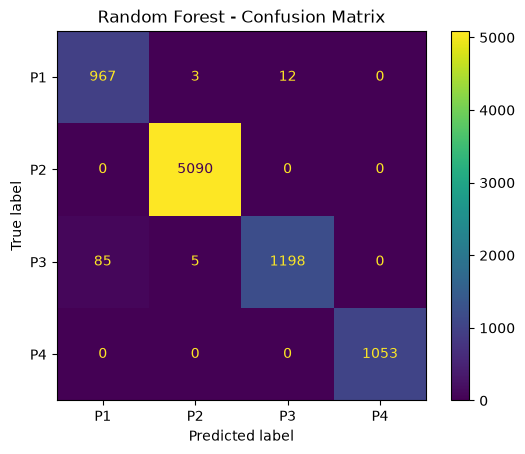

In [32]:
# Random Forest confusion matrix

cm_rf = confusion_matrix(
    y_test,
    rf_pred,
    labels=["P1", "P2", "P3", "P4"]
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=["P1", "P2", "P3", "P4"]
)

disp.plot()
plt.title("Random Forest - Confusion Matrix")
plt.show()

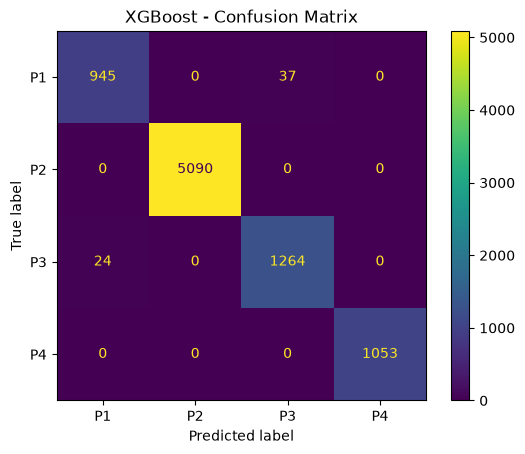

In [33]:
# XGBoost confusion matrix

cm_xgb = confusion_matrix(
    y_test_xgb,
    xgb_pred,
    labels=[0, 1, 2, 3]
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_xgb,
    display_labels=label_encoder.classes_
)

disp.plot()
plt.title("XGBoost - Confusion Matrix")
plt.show()

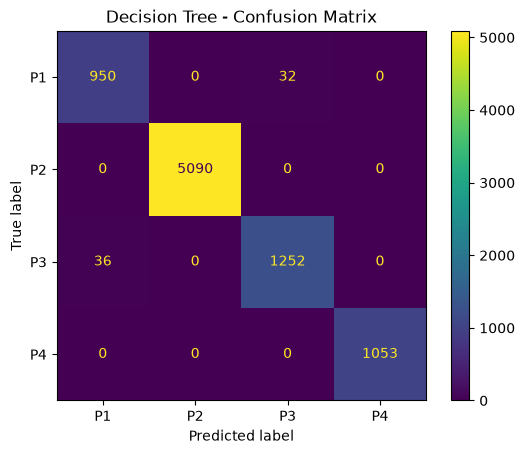

In [34]:
# Decision Tree confusion matrix

cm_dt = confusion_matrix(
    y_test,
    dt_pred,
    labels=["P1", "P2", "P3", "P4"]
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_dt,
    display_labels=["P1", "P2", "P3", "P4"]
)

disp.plot()
plt.title("Decision Tree - Confusion Matrix")
plt.show()

## 16. Model Interpretation

For this multiclass credit-risk problem, compare the models using:

- **Accuracy** — overall percentage of correct predictions.
- **Precision** — how reliable the predictions for each class are.
- **Recall** — how many actual cases of each class are identified.
- **F1 Score** — balance between precision and recall.

The final model should not be selected from accuracy alone. Review the class-wise metrics and confusion matrix, especially because the target has four classes.


In [35]:
# Optional: feature importance from Random Forest

rf_feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_classifier.feature_importances_
}).sort_values(
    by="Importance",
    ascending=False
)

rf_feature_importance.head(20)

,Feature,Importance
47,Credit_Score,0.543178
13,Age_Oldest_TL,0.067507
35,enq_L3m,0.055159
34,time_since_recent_enq,0.037387
20,num_std,0.026756
21,num_std_6mts,0.020483
43,pct_PL_enq_L6m_of_ever,0.017896
33,PL_enq_L6m,0.014810
29,tot_enq,0.014337
17,max_recent_level_of_deliq,0.012242


In [36]:
# Optional: feature importance from Decision Tree

dt_feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": dt_model.feature_importances_
}).sort_values(
    by="Importance",
    ascending=False
)

dt_feature_importance.head(20)

,Feature,Importance
47,Credit_Score,0.992506
37,NETMONTHLYINCOME,0.001069
34,time_since_recent_enq,0.000789
39,pct_of_active_TLs_ever,0.000520
38,Time_With_Curr_Empr,0.000412
16,num_times_delinquent,0.000377
14,Age_Newest_TL,0.000344
15,time_since_recent_payment,0.000317
36,AGE,0.000309
10,Gold_TL,0.000285


## ROC-AUC Evaluation

ROC-AUC is calculated using the model's class probabilities. Since this is a multiclass problem (P1, P2, P3, P4), the **macro One-vs-Rest ROC-AUC** is reported.

In [38]:
# ============================================================
# ROC-AUC SCORES FOR ALL MODELS
# ============================================================

from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import pandas as pd

roc_classes = ["P1", "P2", "P3", "P4"]

# ============================================================
# RANDOM FOREST
# ============================================================

# Random Forest uses X_test and y_test
rf_prob = rf_classifier.predict_proba(X_test)

y_test_binary = label_binarize(
    y_test,
    classes=roc_classes
)

rf_auc = roc_auc_score(
    y_test_binary,
    rf_prob,
    average="macro"
)

# ============================================================
# XGBOOST
# ============================================================

# XGBoost uses encoded y_test_xgb
xgb_prob = xgb_classifier.predict_proba(X_test_xgb)

xgb_auc = roc_auc_score(
    label_binarize(
        y_test_xgb,
        classes=[0, 1, 2, 3]
    ),
    xgb_prob,
    average="macro"
)

# ============================================================
# DECISION TREE
# ============================================================

# Decision Tree uses X_test and y_test
dt_prob = dt_model.predict_proba(X_test)

dt_auc = roc_auc_score(
    y_test_binary,
    dt_prob,
    average="macro"
)

# ============================================================
# ROC-AUC COMPARISON TABLE
# ============================================================

roc_auc_results = [
    {
        "Model": "Random Forest",
        "ROC-AUC": rf_auc
    },
    {
        "Model": "XGBoost",
        "ROC-AUC": xgb_auc
    },
    {
        "Model": "Decision Tree",
        "ROC-AUC": dt_auc
    }
]

roc_auc_df = pd.DataFrame(
    roc_auc_results
).sort_values(
    by="ROC-AUC",
    ascending=False
).reset_index(drop=True)

print("Multiclass Macro ROC-AUC:")
display(roc_auc_df)

Multiclass Macro ROC-AUC:


,Model,ROC-AUC
0,XGBoost,0.999832
1,Random Forest,0.999461
2,Decision Tree,0.993324


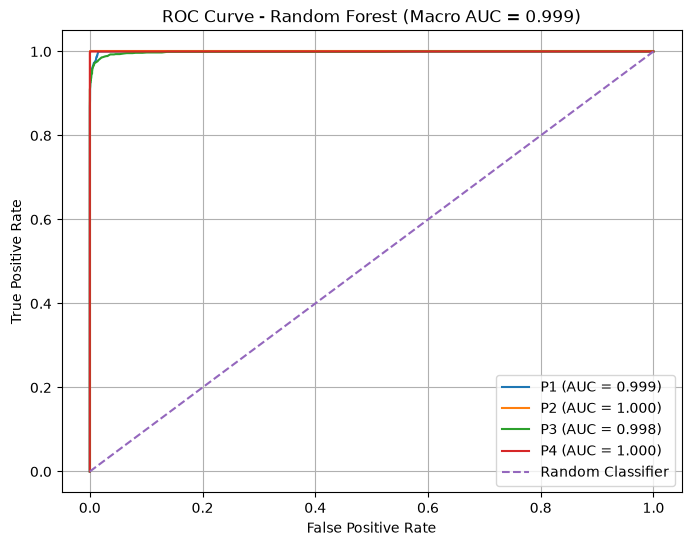

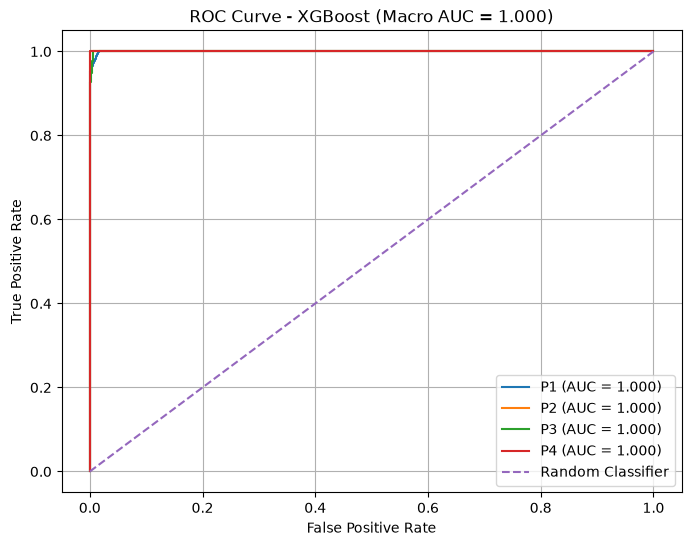

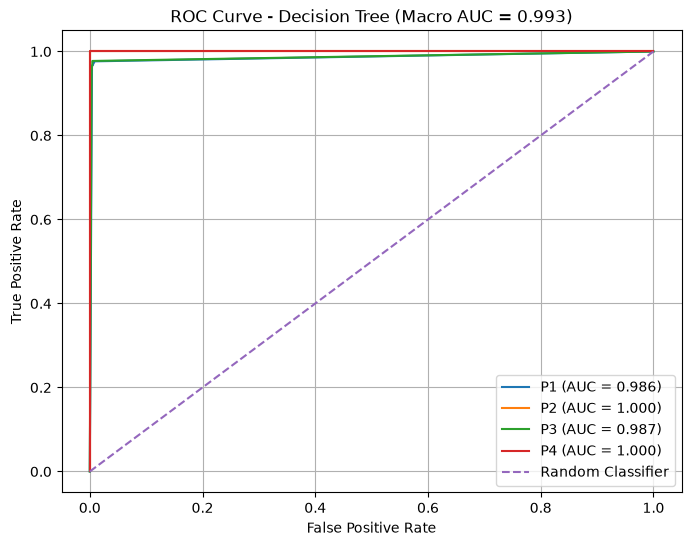

In [39]:
# ============================================================
# ROC CURVES - ONE-VS-REST
# ============================================================

model_probabilities = {
    "Random Forest": rf_prob,
    "XGBoost": xgb_prob,
    "Decision Tree": dt_prob
}

# Use the correct binary test labels for each model
model_binary_labels = {
    "Random Forest": y_test_binary,
    "XGBoost": label_binarize(
        y_test_xgb,
        classes=[0, 1, 2, 3]
    ),
    "Decision Tree": y_test_binary
}

for model_name, probabilities in model_probabilities.items():

    binary_labels = model_binary_labels[model_name]

    plt.figure(figsize=(8, 6))

    for class_index, class_name in enumerate(roc_classes):

        fpr, tpr, _ = roc_curve(
            binary_labels[:, class_index],
            probabilities[:, class_index]
        )

        class_auc = roc_auc_score(
            binary_labels[:, class_index],
            probabilities[:, class_index]
        )

        plt.plot(
            fpr,
            tpr,
            label=f"{class_name} (AUC = {class_auc:.3f})"
        )

    # Random classifier reference
    plt.plot(
        [0, 1],
        [0, 1],
        linestyle="--",
        label="Random Classifier"
    )

    # Macro ROC-AUC
    macro_auc = roc_auc_score(
        binary_labels,
        probabilities,
        average="macro"
    )

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")

    plt.title(
        f"ROC Curve - {model_name} "
        f"(Macro AUC = {macro_auc:.3f})"
    )

    plt.legend()
    plt.grid(True)
    plt.show()

### ROC-AUC Interpretation

- **ROC-AUC closer to 1.0** → better ability to distinguish the credit-risk classes.
- **ROC-AUC around 0.5** → performance is close to random classification.
- The **Macro ROC-AUC** gives equal importance to P1, P2, P3 and P4.

### **SAVE XGBOOST MODEL + LABEL ENCODER + FEATURE NAMES**

In [40]:
import joblib

# Save model
joblib.dump(
    xgb_classifier,
    "xgboost_credit_risk_model.pkl"
)

# Save target label encoder
joblib.dump(
    label_encoder,
    "xgboost_label_encoder.pkl"
)

# Save feature names/order
joblib.dump(
    list(X.columns),
    "xgboost_feature_names.pkl"
)

print("XGBoost model artifacts saved successfully.")
print("1. xgboost_credit_risk_model.pkl")
print("2. xgboost_label_encoder.pkl")
print("3. xgboost_feature_names.pkl")

XGBoost model artifacts saved successfully.
1. xgboost_credit_risk_model.pkl
2. xgboost_label_encoder.pkl
3. xgboost_feature_names.pkl


## Final Interview Summary

> This project is a multiclass credit-risk classification problem. I cleaned and merged two datasets using `PROSPECTID`, performed statistical feature selection using Chi-square, VIF and ANOVA, encoded categorical variables, and split the data into training and testing sets. I then trained Random Forest, XGBoost and Decision Tree models and compared them using accuracy, precision, recall and weighted F1 score. I also used class-wise classification reports and confusion matrices to understand model performance across P1, P2, P3 and P4.
